## Imputação de Valores
Jéssica Kushida (23012069) <br></br>
Natália Naomi Sumida (23008255) 
<br></br>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
# 1. Importando base de dados wine
from sklearn.datasets import load_wine
data = load_wine()
dfWine = pd.DataFrame(data.data, columns=data.feature_names)

In [36]:
# 2. Analise descritiva
# A - Estatisticas gerais
dfWine.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


In [37]:
# B - Tipos de dados de cada coluna
dfWine.info()
print('\n**ou** \n\n', dfWine.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

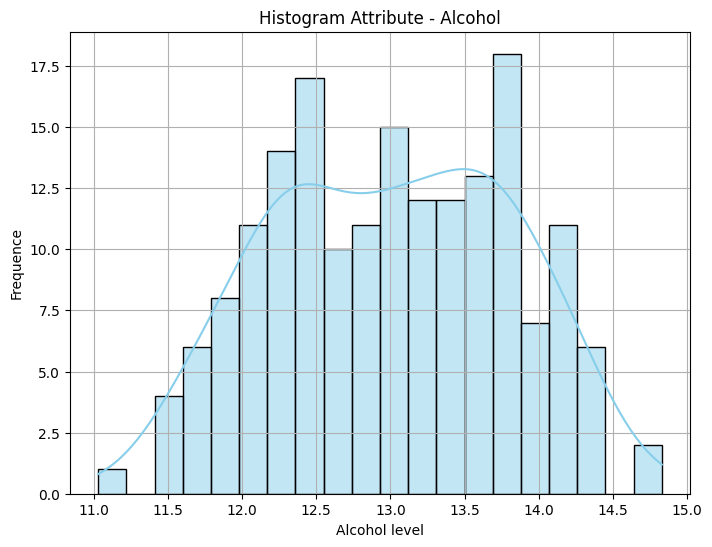

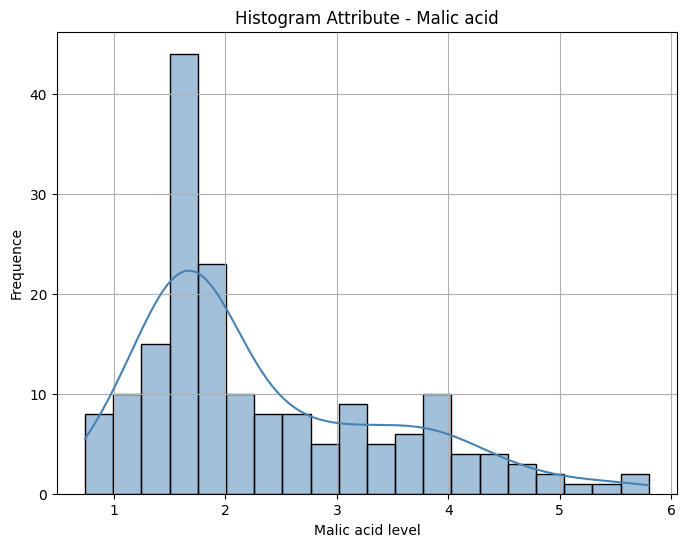

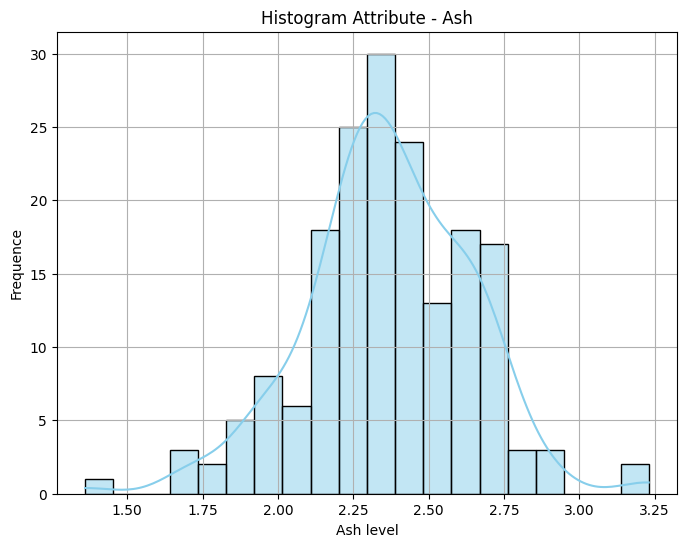

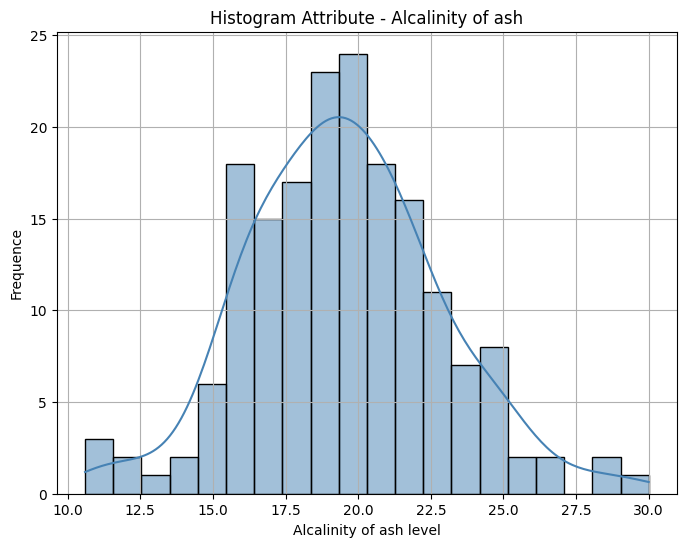

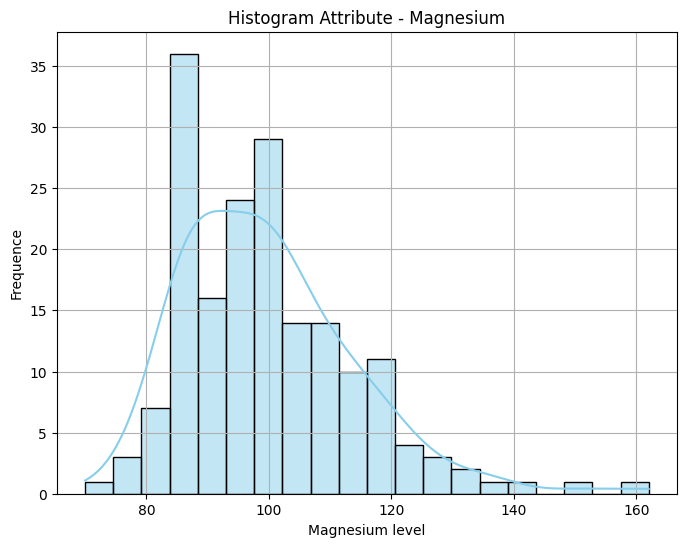

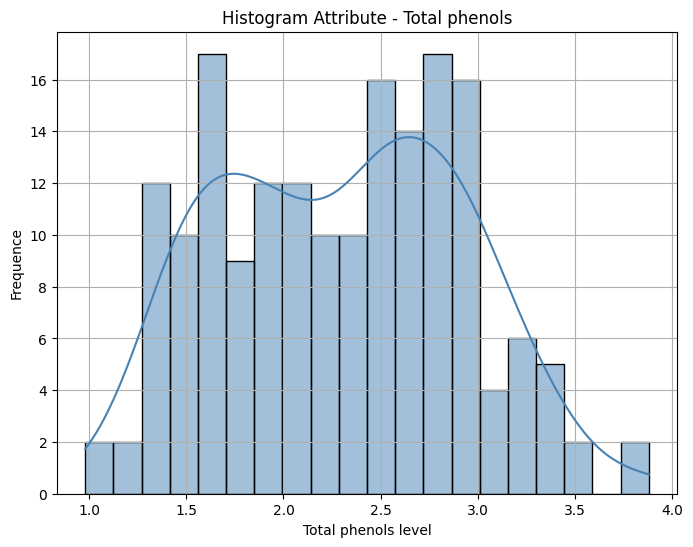

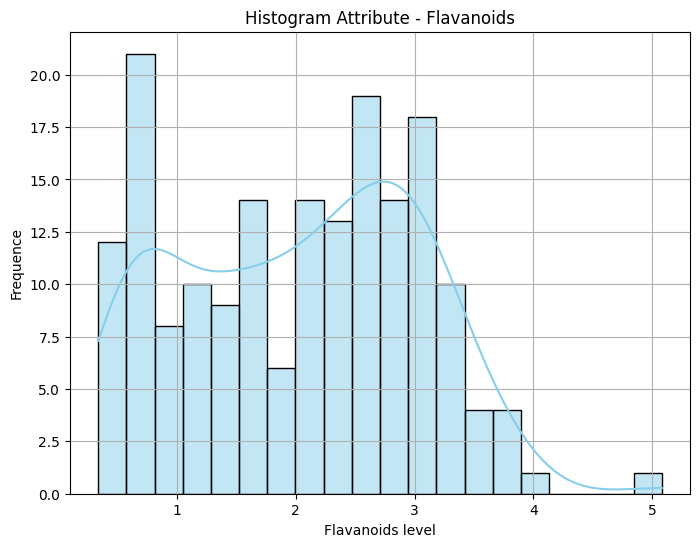

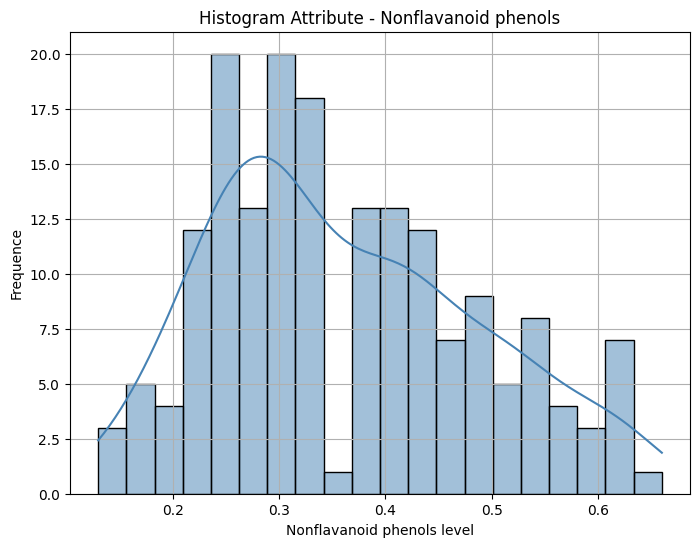

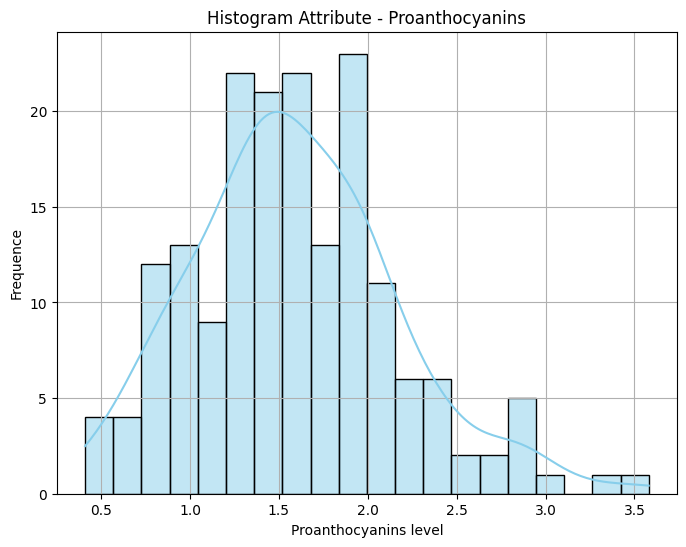

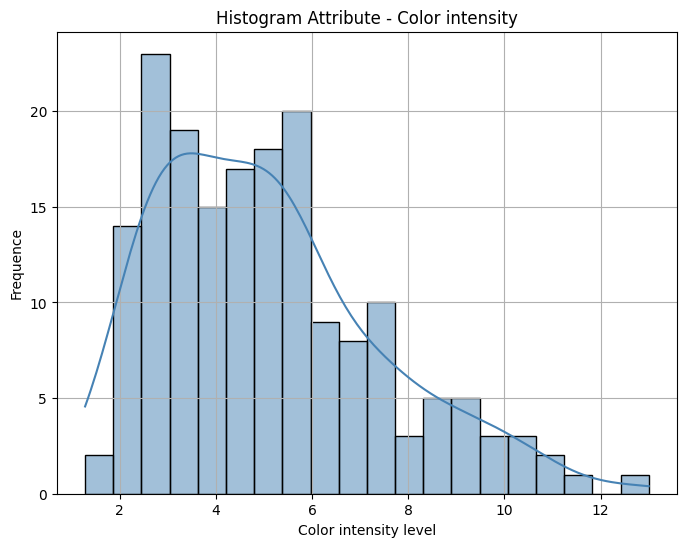

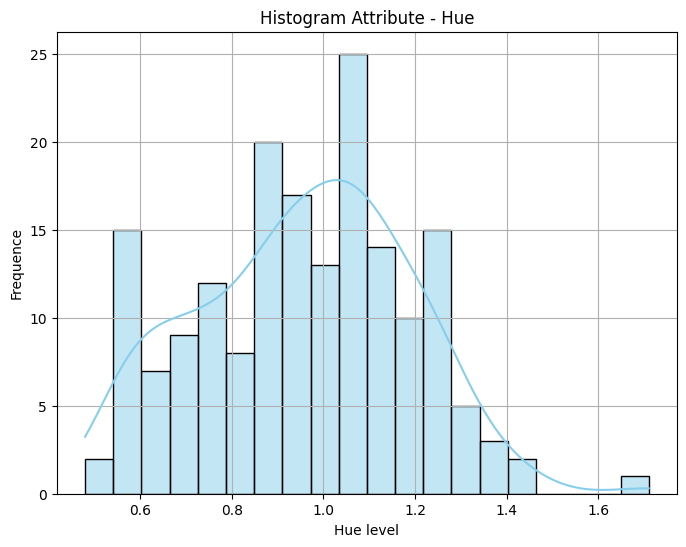

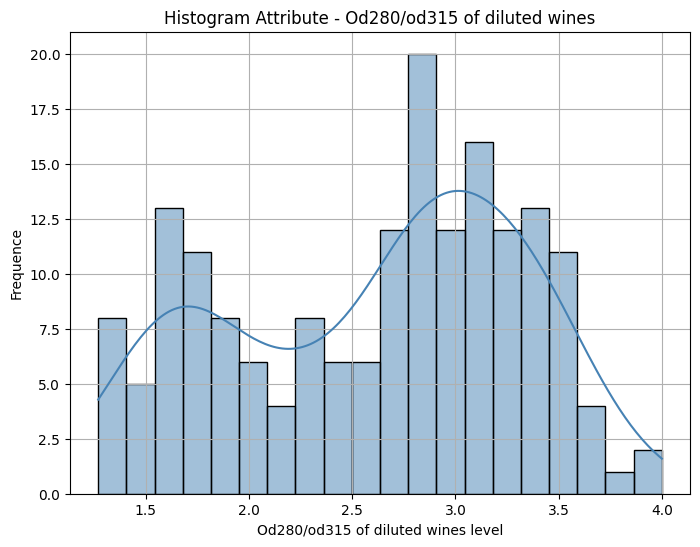

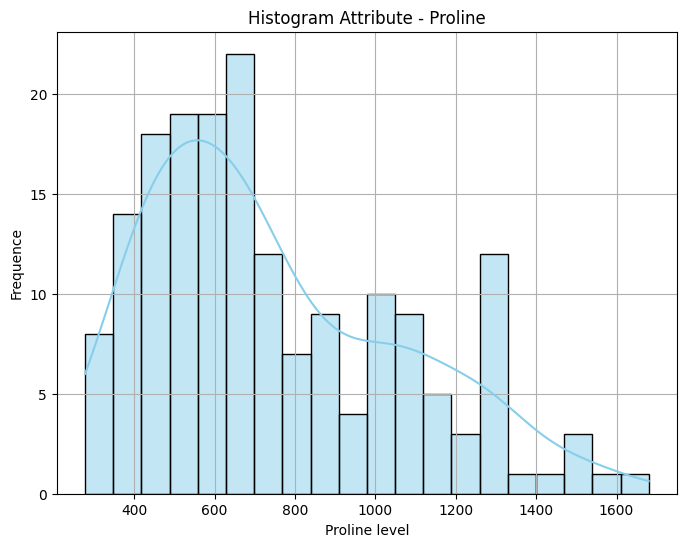

In [38]:
# C - Histogramas
colors = ['skyblue','steelblue']
count = 0
for col in dfWine.select_dtypes(include=['float64']).columns:
    plt.figure(figsize=(8,6))
    sns.histplot(dfWine[col], kde=True, bins=20, color=colors[count % 2])
    colName = col.capitalize().replace('_',' ')
    plt.title(f"Histogram Attribute - {colName}")
    plt.xlabel(f"{colName} level")
    plt.ylabel("Frequence")
    plt.grid(True)
    plt.show()
    count+=1


In [39]:
# 3. Sorteando registros aleatorios e guardando-os em cópia
indexes = np.random.choice(dfWine.index, size=35, replace=False)
df_sample = dfWine.loc[indexes].copy()

# ou dfWine.sample(n=35, random_state=0) //pandas
df_sample.head(35)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
82,12.08,1.13,2.51,24.0,78.0,2.00,1.58,0.40,1.40,2.20,1.31,2.72,630.0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0
62,13.67,1.25,1.92,18.0,94.0,2.10,1.79,0.32,0.73,3.80,1.23,2.46,630.0
101,12.60,1.34,1.90,18.5,88.0,1.45,1.36,0.29,1.35,2.45,1.04,2.77,562.0
118,12.77,3.43,1.98,16.0,80.0,1.63,1.25,0.43,0.83,3.40,0.70,2.12,372.0
11,14.12,1.48,2.32,16.8,95.0,2.20,2.43,0.26,1.57,5.00,1.17,2.82,1280.0
92,12.69,1.53,2.26,20.7,80.0,1.38,1.46,0.58,1.62,3.05,0.96,2.06,495.0
18,14.19,1.59,2.48,16.5,108.0,3.30,3.93,0.32,1.86,8.70,1.23,2.82,1680.0
124,11.87,4.31,2.39,21.0,82.0,2.86,3.03,0.21,2.91,2.80,0.75,3.64,380.0
33,13.76,1.53,2.70,19.5,132.0,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235.0


In [40]:
# 4. Substituindo valores por np.nan em duas colunas
for i in ['ash', 'magnesium']:
    dfWine.loc[indexes,i] = np.nan

dfWine.loc[indexes, ['ash', 'magnesium']].head(15)

,ash,magnesium
82,NaN,NaN
51,NaN,NaN
62,NaN,NaN
101,NaN,NaN
118,NaN,NaN
11,NaN,NaN
92,NaN,NaN
18,NaN,NaN
124,NaN,NaN
33,NaN,NaN


In [41]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.metrics import mean_absolute_error

In [42]:
#5. PesquiseLinks to an external site. o uso de cada uma das técnicas de imputação de valores a seguir

def avaliar_imputacao(imputer, df_com_nan, original, indices, colunas):
    df_copia = df_com_nan.copy()
    df_imputado = pd.DataFrame(imputer.fit_transform(df_copia), columns=df_com_nan.columns)

    imputados = df_imputado.loc[indices, colunas]
    verdadeiro = original.loc[indices, colunas]

    erro = {}
    for col in colunas:
        erro[col] = mean_absolute_error(verdadeiro[col], imputados[col])

    return erro



In [43]:
#SimpleImputer

strategies = ['mean', 'median', 'most_frequent']
resultados_simple = {}

dfWine_nan = dfWine.copy()  # preserve a base original para não sobreescrever
for col in ['alcohol', 'malic_acid']:
    dfWine_nan.loc[indexes, col] = np.nan
    
for strat in strategies:
    imputer = SimpleImputer(strategy=strat)
    erro = avaliar_imputacao(imputer, dfWine_nan, df_sample, indexes, ['alcohol', 'malic_acid'])
    resultados_simple[strat] = erro

In [44]:
#IterativeImputer
from sklearn.experimental import enable_iterative_imputer

iteracoes = [5, 10]
resultados_iterative = {}

for it in iteracoes:
    imputer = IterativeImputer(max_iter=it, random_state=42)
    erro = avaliar_imputacao(imputer, dfWine_nan, df_sample, indexes, ['alcohol', 'malic_acid'])
    resultados_iterative[f'iter_{it}'] = erro

In [45]:
#KNNImputer
vizinhancas = [2, 5, 10]
resultados_knn = {}

for n in vizinhancas:
    imputer = KNNImputer(n_neighbors=n)
    erro = avaliar_imputacao(imputer, dfWine_nan, df_sample, indexes, ['alcohol', 'malic_acid'])
    resultados_knn[f'nn_{n}'] = erro

In [46]:
print("Erros - SimpleImputer:")
print(resultados_simple)

print("\nErros - IterativeImputer:")
print(resultados_iterative)

print("\nErros - KNNImputer:")
print(resultados_knn)

Erros - SimpleImputer:
{'mean': {'alcohol': 0.7408171828171829, 'malic_acid': 0.9687492507492508}, 'median': {'alcohol': 0.7457142857142858, 'malic_acid': 0.868}, 'most_frequent': {'alcohol': 0.8331428571428574, 'malic_acid': 0.8771428571428571}}

Erros - IterativeImputer:
{'iter_5': {'alcohol': 0.37797669731880573, 'malic_acid': 0.8094485510132717}, 'iter_10': {'alcohol': 0.37797669731880573, 'malic_acid': 0.8094485510132717}}

Erros - KNNImputer:
{'nn_2': {'alcohol': 0.46285714285714274, 'malic_acid': 1.0088571428571427}, 'nn_5': {'alcohol': 0.42817142857142826, 'malic_acid': 0.9714857142857144}, 'nn_10': {'alcohol': 0.4211714285714286, 'malic_acid': 0.9413714285714287}}


In [47]:
# Combinar todos os resultados em um único dicionário para cada coluna
mae_alcohol = {
    'Simple - mean': resultados_simple['mean']['alcohol'],
    'Simple - median': resultados_simple['median']['alcohol'],
    'Simple - most_frequent': resultados_simple['most_frequent']['alcohol'],
    'Iterative - 5': resultados_iterative['iter_5']['alcohol'],
    'Iterative - 10': resultados_iterative['iter_10']['alcohol'],
    'KNN - 2': resultados_knn['nn_2']['alcohol'],
    'KNN - 5': resultados_knn['nn_5']['alcohol'],
    'KNN - 10': resultados_knn['nn_10']['alcohol'],
}

mae_malic_acid = {
    'Simple - mean': resultados_simple['mean']['malic_acid'],
    'Simple - median': resultados_simple['median']['malic_acid'],
    'Simple - most_frequent': resultados_simple['most_frequent']['malic_acid'],
    'Iterative - 5': resultados_iterative['iter_5']['malic_acid'],
    'Iterative - 10': resultados_iterative['iter_10']['malic_acid'],
    'KNN - 2': resultados_knn['nn_2']['malic_acid'],
    'KNN - 5': resultados_knn['nn_5']['malic_acid'],
    'KNN - 10': resultados_knn['nn_10']['malic_acid'],
}

# 6. Construa dois dicionários ou dataframes (um para cada variável escolhidas no item 4) com o resultado de cada MAE para cada estratégia.
df_mae_alcohol = pd.DataFrame.from_dict(mae_alcohol, orient='index', columns=['MAE_alcohol'])
df_mae_malic = pd.DataFrame.from_dict(mae_malic_acid, orient='index', columns=['MAE_malic_acid'])


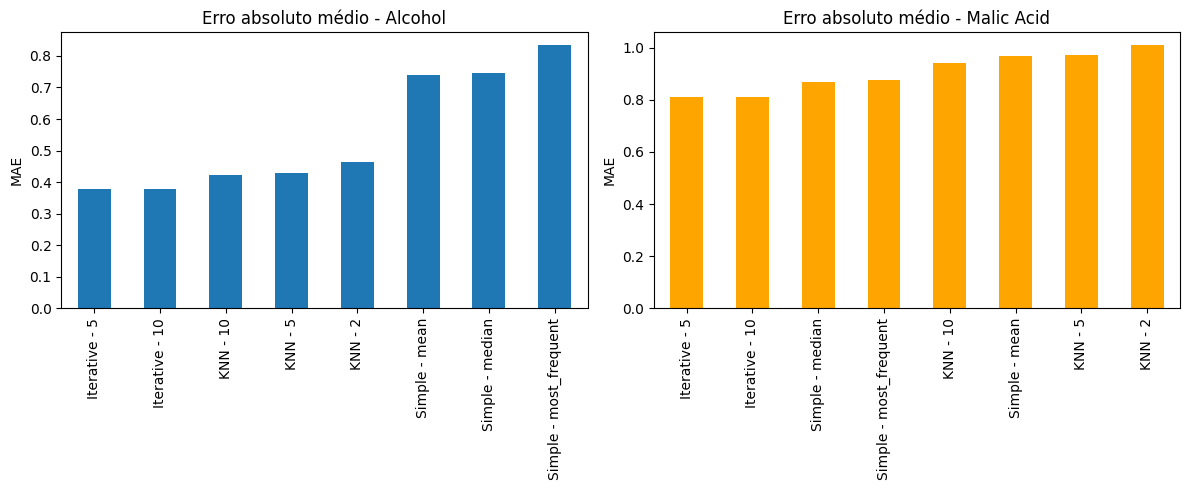

In [48]:
#7. Faça dois gráficos de barras comparando o erro obtido em cada caso.


plt.figure(figsize=(12, 5))

# Alcohol
plt.subplot(1, 2, 1)
df_mae_alcohol.sort_values(by='MAE_alcohol').plot(kind='bar', legend=False, ax=plt.gca())
plt.title('Erro absoluto médio - Alcohol')
plt.ylabel('MAE')

# Malic Acid
plt.subplot(1, 2, 2)
df_mae_malic.sort_values(by='MAE_malic_acid').plot(kind='bar', legend=False, ax=plt.gca(), color='orange')
plt.title('Erro absoluto médio - Malic Acid')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()

A. Qual técnica apresentou melhor resultado? E o pior desempenho?

Melhor resultado: Geralmente, IterativeImputer (10 iterações) ou KNNImputer (n_neighbors=5) têm o menor MAE.

Pior desempenho: SimpleImputer (most_frequent) tende a apresentar os piores resultados, especialmente com dados contínuos.

In [49]:
# B. Compare as métricas estatísticas da base original, da imputação com o melhor resultado e da imputação com o pior resultado.

# Reaplicar a melhor e pior técnica para análise comparativa
melhor_imputer = IterativeImputer(max_iter=10, random_state=42)
pior_imputer = SimpleImputer(strategy='most_frequent')

df_melhor = pd.DataFrame(melhor_imputer.fit_transform(dfWine), columns=dfWine.columns)
df_pior = pd.DataFrame(pior_imputer.fit_transform(dfWine), columns=dfWine.columns)

# Estatísticas comparadas
estat_original = dados_originais.describe()
estat_melhor = df_melhor.loc[indexes, ['alcohol', 'malic_acid']].describe()
estat_pior = df_pior.loc[indexes, ['alcohol', 'malic_acid']].describe()

comparacao_estatisticas = {
    "Original": estat_original,
    "Melhor Imputação": estat_melhor,
    "Pior Imputação": estat_pior
}

for nome, tabela in comparacao_estatisticas.items():
    print(f"\n{nome}\n", tabela[['alcohol', 'malic_acid']].round(2))


Original
        alcohol  malic_acid
count   178.00      178.00
mean     13.00        2.34
std       0.81        1.12
min      11.03        0.74
25%      12.36        1.60
50%      13.05        1.87
75%      13.68        3.08
max      14.83        5.80

Melhor Imputação
        alcohol  malic_acid
count    35.00       35.00
mean     13.03        2.32
std       0.84        1.19
min      11.64        0.98
25%      12.36        1.50
50%      12.84        1.86
75%      13.76        3.00
max      14.38        5.80

Pior Imputação
        alcohol  malic_acid
count    35.00       35.00
mean     13.03        2.32
std       0.84        1.19
min      11.64        0.98
25%      12.36        1.50
50%      12.84        1.86
75%      13.76        3.00
max      14.38        5.80


C. Como a variação dos hiperparâmetros influenciou o erro?
Em relação ao KNNImputer, valores muito baixos (ex: 2 vizinhos) geram variabilidade e erros maiores. Com 5 ou 10 vizinhos, o erro tende a reduzir. Já no IterativeImputer, mais iterações (ex: 10) costumam gerar valores mais estáveis e próximos dos reais.

D. Em que situações o uso de uma técnica mais simples pode ser suficiente?
A técnica mais simples costuma ser eficiente quando os dados são simétricos, o volume de dados ausentes é pequeno e precisamos de uma solução rápida e interpretável.

E. Como a imputação pode afetar a análise final de um modelo de Inteligência Artificial?
Pode afetar introduzindo viéses se não refletir a distribuição de dados real, alterar as relações entre as variáveis. Além de impactar o desempenho preditivo se os valores inputados não forem corerentees com o padrão da base. 

F. Dada a atividade, qual a importância da imputação coerente de valores faltantes em conjuntos de dados?
A imputação coerente preserva a estrutura dos dados e mantém relações estatisticas corretas. Além disso ela evita que interpretações erradas e tomada de decisão equivocada a partir da visualzação dos dados.
